## Imports

In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import os
import sys
import matplotlib.pyplot as plt

#CHANGE AS NEEDED
sys.path.append('/home/patrick/ansermodelling')
os.chdir("/home/patrick/ansermodelling")


from models.FFNN_network import FFNN
from data.anser_dataset import AnserDataset
from models.train import train


## Dataset

In [2]:
dataset = AnserDataset("data/dataset.npz")

### Spatial Distribution

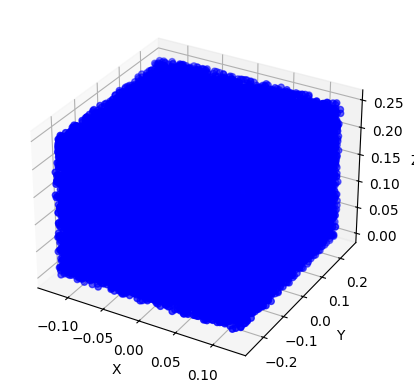

In [3]:
positions = dataset.y[:,:3]

# Create a new figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Create a scatter plot
ax.scatter(positions[:,0], positions[:,1], positions[:,2], c='blue', marker='o')

# Set labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Show the plot
plt.show()

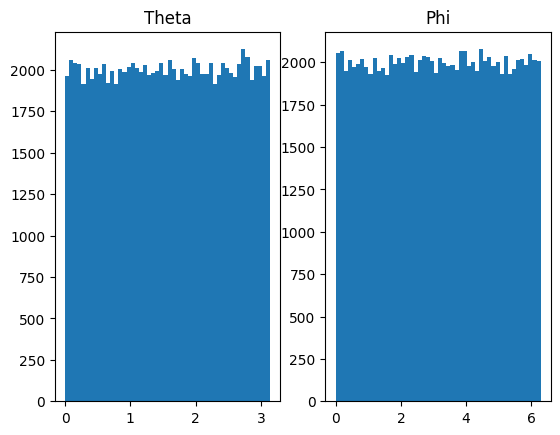

In [4]:
theta = dataset.y[:, 3]
phi = dataset.y[:, 4]

fig, axes = plt.subplots(1, 2)
axes[0].hist(theta, bins=50)
axes[0].set_title("Theta")
axes[1].hist(phi, bins=50)
axes[1].set_title("Phi")
plt.show()

Distrubtion of Fluxes

-0.0054432433
17.87918


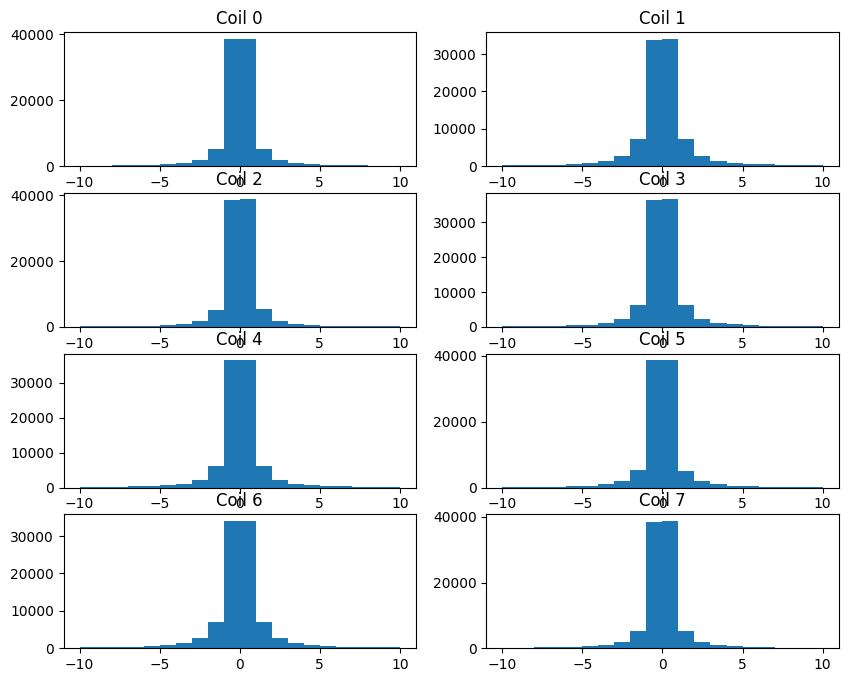

In [5]:
fluxes = dataset.x.numpy()
fig, axes = plt.subplots(4, 2, figsize=(10, 8))

print(np.mean(fluxes))
print(np.std(fluxes))

for ax, i in zip(axes.flat, range(8)):
    ax.hist(fluxes[:, i], bins=20,range=(-10, 10))
    ax.set_title(f"Coil {i}")
plt.show()

In [3]:
from torch.utils.data import random_split
n = len(dataset)
n_train = int(0.8 * n)
n_test = n - n_train

train_set, test_set = random_split(dataset, [n_train, n_test])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

In [4]:
model = FFNN(input_dim=8, output_dim=5, hidden_dims=[64,256,64])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [5]:
train_losses, test_losses = train(model, train_loader, test_loader, optimizer, epochs=50, print_losses = True)

epoch 	 Training Loss 	 Test Loss 	 Mean pos error train 	 Mean Pos Error Test
1 	 0.6547 	  0.5010 	 0.1256 	 0.1055
2 	 0.4501 	  0.4118 	 0.0980 	 0.0909
3 	 0.3963 	  0.4024 	 0.0917 	 0.0924
4 	 0.3696 	  0.3624 	 0.0898 	 0.0890
5 	 0.3524 	  0.3473 	 0.0896 	 0.0880
6 	 0.3402 	  0.3415 	 0.0893 	 0.0887
7 	 0.3288 	  0.3650 	 0.0897 	 0.0874
8 	 0.3199 	  0.3319 	 0.0892 	 0.0878
9 	 0.3133 	  0.3154 	 0.0894 	 0.0923
10 	 0.3050 	  0.3121 	 0.0892 	 0.0903
11 	 0.3003 	  0.3003 	 0.0886 	 0.0868
12 	 0.2944 	  0.3088 	 0.0884 	 0.0889
13 	 0.2908 	  0.3027 	 0.0879 	 0.0898
14 	 0.2857 	  0.2897 	 0.0882 	 0.0863
15 	 0.2800 	  0.2991 	 0.0879 	 0.0877
16 	 0.2770 	  0.2817 	 0.0885 	 0.0892
17 	 0.2729 	  0.2970 	 0.0881 	 0.0875
18 	 0.2705 	  0.2871 	 0.0879 	 0.0878
19 	 0.2673 	  0.2883 	 0.0883 	 0.0870
20 	 0.2630 	  0.2862 	 0.0879 	 0.0883
21 	 0.2606 	  0.2873 	 0.0873 	 0.0886
22 	 0.2578 	  0.2762 	 0.0863 	 0.0863
23 	 0.2554 	  0.2832 	 0.0855 	 0.0838
24 	 0.254

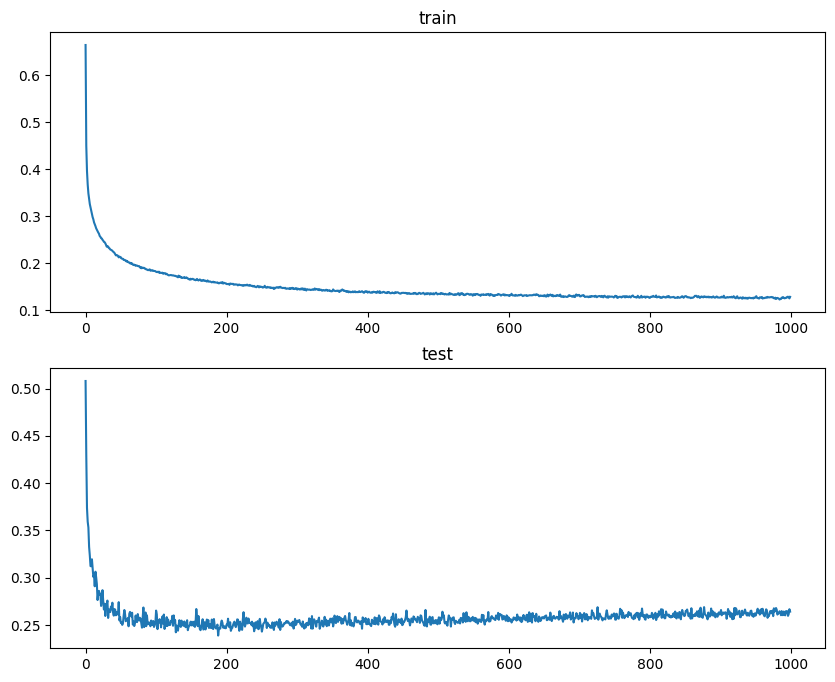

In [9]:
fig, axes = plt.subplots(2,figsize=(10, 8))
axes[0].plot(train_losses)
axes[0].set_title("train")
axes[1].plot(test_losses)
axes[1].set_title("test")
plt.show()


Looks like I might be overfitting. I think I might normalise the data 